In [1]:

import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

## Part 1: Creating new folder with the right structure

In [2]:
import os
import shutil
# Updated source path to account for the nested structure
source_root = "recycling/images/images"
target_root = "dataset"
# Define your mapping from fine-grained folders to broad waste categories
category_map = {
    "plastic": [
        "water_bottles", "soda_bottles", "detergent_bottles", "shopping_bags", "trash_bags",
        "food_containers", "disposable_cutlery", "straws",
        "plastic_water_bottles", "plastic_food_containers", "plastic_shopping_bags", "plastic_soda_bottles",
        "plastic_trash_bags", "disposable_plastic_cutlery", "plastic_cup_lids"
    ],
    "paper_and_cardboard": [
        "newspaper", "office_paper", "magazines", "cardboard_boxes", "cardboard_packaging",
        "paper_cups"
    ],
    "glass": [
        "beverage_bottles", "food_jars", "cosmetic_containers",
        "glass_beverage_bottles", "glass_food_jars", "glass_cosmetic_containers"
    ],
    "metal": [
        "aluminum_soda_cans", "aluminum_food_cans", "steel_food_cans", "aerosol_cans"
    ],
    "organic_waste": [
        "food_waste", "fruit_peels", "vegetable_scraps", "eggshells", "coffee_grounds", "tea_bags"
    ],
    "textiles": [
        "clothing", "shoes"
    ],
    "other": [
        "styrofoam_cups", "styrofoam_food_containers"
    ]
}
# Reverse map: from specific folder to category
folder_to_category = {}
for category, subfolders in category_map.items():
    for folder in subfolders:
        folder_to_category[folder] = category
# Loop through source folder (e.g., recycling/images/images/)
for folder_name in os.listdir(source_root):
    folder_path = os.path.join(source_root, folder_name)
    if not os.path.isdir(folder_path):
        continue
    # Normalize folder name like "plastic_water_bottles" → "water_bottles"
    for sublabel in folder_to_category:
        if sublabel in folder_name:
            category = folder_to_category[sublabel]
            break
    else:
        print(f":warning: Skipping unknown folder: {folder_name}")
        continue
    target_folder = os.path.join(target_root, category)
    os.makedirs(target_folder, exist_ok=True)
    # Look inside "default" and "real_world" subfolders
    for variation in ["default", "real_world"]:
        variation_path = os.path.join(folder_path, variation)
        if not os.path.isdir(variation_path):
            continue
        for fname in os.listdir(variation_path):
            src = os.path.join(variation_path, fname)
            dst = os.path.join(target_folder, fname)
            try:
                shutil.copy2(src, dst)
            except Exception as e:
                print(f"Error copying {src} → {e}")
print("Images grouped (from both default & real_world) into super-categories!")

Images grouped (from both default & real_world) into super-categories!


In [3]:
import random

In [4]:
# Split the dataset into train, validation, and test sets
def split_dataset(source_dir, output_dir, split_ratio=(0.7, 0.15, 0.15), seed=42):
    assert sum(split_ratio) == 1.0, "Split ratios must add up to 1"
    random.seed(seed)
    classes = os.listdir(source_dir)
    for cls in classes:
        class_dir = os.path.join(source_dir, cls)
        if not os.path.isdir(class_dir):
            continue
        images = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
        random.shuffle(images)
        n_total = len(images)
        n_train = int(n_total * split_ratio[0])
        n_val = int(n_total * split_ratio[1])
        n_test = n_total - n_train - n_val
        split_points = {
            'train': images[:n_train],
            'val': images[n_train:n_train + n_val],
            'test': images[n_train + n_val:]
        }
        for split_name, split_files in split_points.items():
            split_class_dir = os.path.join(output_dir, split_name, cls)
            os.makedirs(split_class_dir, exist_ok=True)
            for fname in split_files:
                src = os.path.join(class_dir, fname)
                dst = os.path.join(split_class_dir, fname)
                shutil.copy2(src, dst)
        print(f"{cls}: {n_total} images split into "
              f"{len(split_points['train'])} train / {len(split_points['val'])} val / {len(split_points['test'])} test")
# Run the split
split_dataset("dataset", "dataset_split", split_ratio=(0.7, 0.15, 0.15))

metal: 250 images split into 175 train / 37 val / 38 test
other: 250 images split into 175 train / 37 val / 38 test
organic_waste: 250 images split into 175 train / 37 val / 38 test
paper_and_cardboard: 250 images split into 175 train / 37 val / 38 test
glass: 250 images split into 175 train / 37 val / 38 test
textiles: 250 images split into 175 train / 37 val / 38 test
plastic: 250 images split into 175 train / 37 val / 38 test


In [5]:
# Creating a path for the dataset
train_dir = os.path.join("dataset_split/train")
val_dir = os.path.join("dataset_split/val")
# Check the directories
print("Train directory:", train_dir)
print("Validation directory:", val_dir)


Train directory: dataset_split/train
Validation directory: dataset_split/val


In [6]:
print("Train directory contents:", os.listdir(train_dir))
print("Validation directory contents:", os.listdir(val_dir))

Train directory contents: ['metal', 'other', 'organic_waste', 'paper_and_cardboard', 'glass', 'textiles', 'plastic']
Validation directory contents: ['metal', 'other', 'organic_waste', 'paper_and_cardboard', 'glass', 'textiles', 'plastic']


## Part 2: Train-Test Split

In [7]:
#create batch size
batch_size = 32
# Set image size
img_size = (160, 160)

In [8]:
train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir, shuffle=True, batch_size=batch_size, image_size=img_size)

validation_dataset = tf.keras.utils.image_dataset_from_directory(val_dir, shuffle=True, batch_size=batch_size, image_size=img_size)

Found 1225 files belonging to 7 classes.
Found 259 files belonging to 7 classes.


In [9]:
class_names = train_dataset.class_names

2025-04-10 23:56:12.936477: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


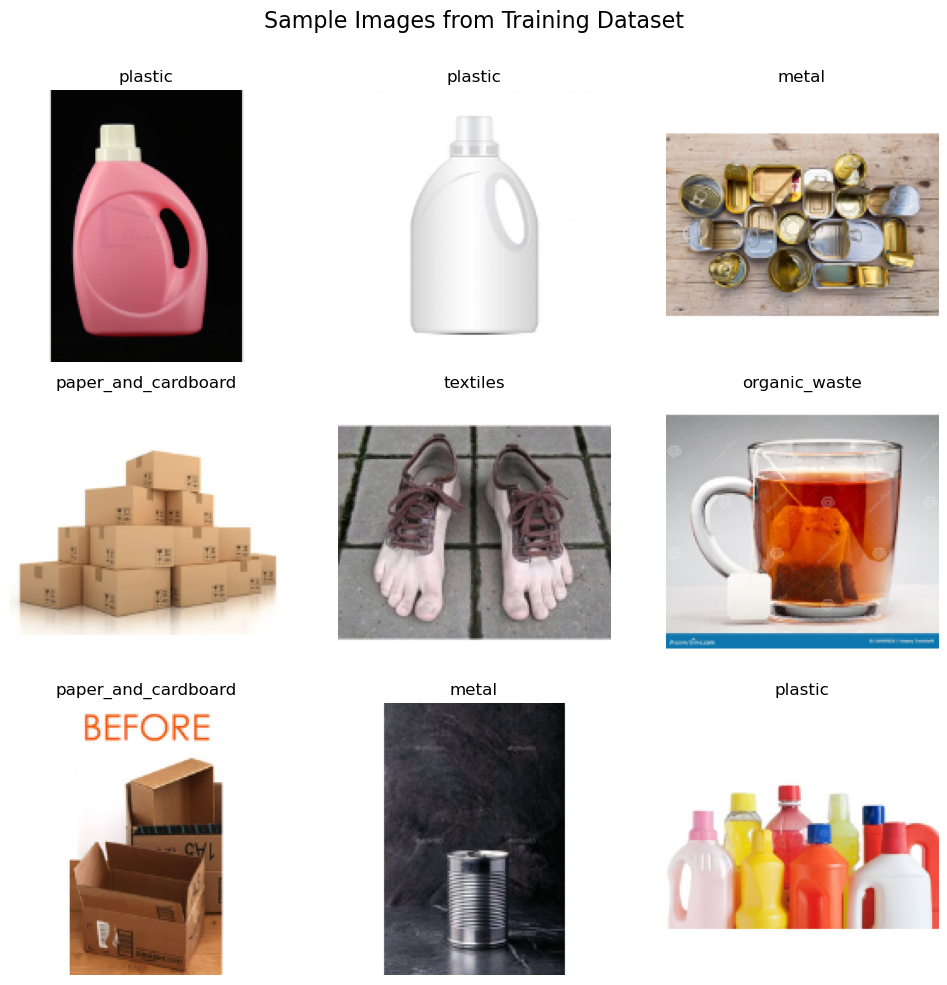

In [10]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Sample Images from Training Dataset", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [11]:
tf.data.AUTOTUNE

-1